Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Loading CSV file
df = pd.read_csv("delivery_data_2409646 (1).csv")  

# Check data
df.head() 

,Unnamed: 0,day_id,demand,vans,employees,total_cost,u,v_sq,e_sq,u_sq,over_util,v2,e2
0,0,1,96,3,6,2562.10,5.052632,9,36,25.529086,0.0,9,36
1,1,2,85,5,10,1617.95,1.666667,25,100,2.777778,0.0,25,100
2,2,3,90,7,8,2066.44,1.578947,49,64,2.493075,0.0,49,64
3,3,4,96,3,15,2622.53,2.086957,9,225,4.355388,0.0,9,225
4,4,5,92,9,13,1895.01,0.779661,81,169,0.607871,0.0,81,169


Task 1 – Understand the Problem & Explore the Data

1.1 Summary Statistics

In [4]:
summary = df[['demand', 'vans', 'employees', 'total_cost']].describe()
print(summary)

           demand        vans   employees  total_cost
count  500.000000  500.000000  500.000000   500.00000
mean    96.222000    5.558000    8.740000  2240.11924
std      9.569319    2.965168    3.720764   718.21076
min     65.000000    1.000000    2.000000   892.81000
25%     90.000000    3.000000    5.750000  1810.20250
50%     96.000000    5.000000    9.000000  2093.93000
75%    103.000000    8.000000   12.000000  2458.25500
max    127.000000   12.000000   16.000000  7048.71000


1.2 Correlation Matrix

In [5]:
corr = df[['demand', 'vans', 'employees', 'total_cost']].corr()
print(corr)

              demand      vans  employees  total_cost
demand      1.000000  0.171627   0.214491   -0.158875
vans        0.171627  1.000000   0.048960   -0.539070
employees   0.214491  0.048960   1.000000   -0.331741
total_cost -0.158875 -0.539070  -0.331741    1.000000


1.3 Visual Exploration

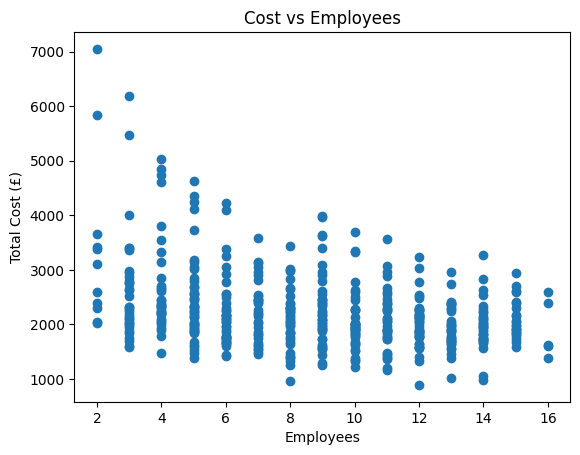

In [12]:

plt.figure()
plt.scatter(df['employees'], df['total_cost'])
plt.xlabel("Employees")
plt.ylabel("Total Cost (£)")
plt.title("Cost vs Employees")
plt.show()


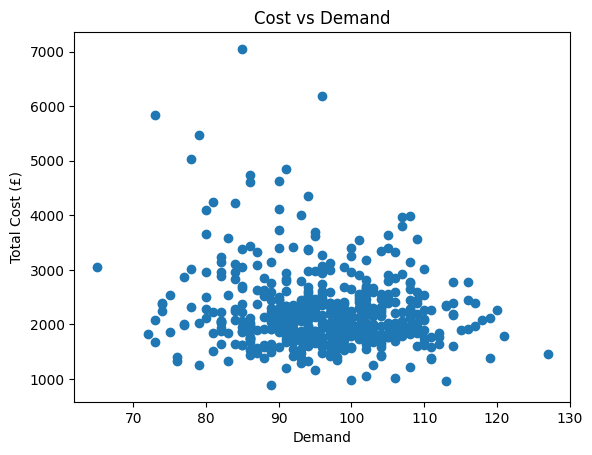

In [13]:
plt.figure()
plt.scatter(df['demand'], df['total_cost'])
plt.xlabel("Demand")
plt.ylabel("Total Cost (£)")
plt.title("Cost vs Demand")
plt.show()

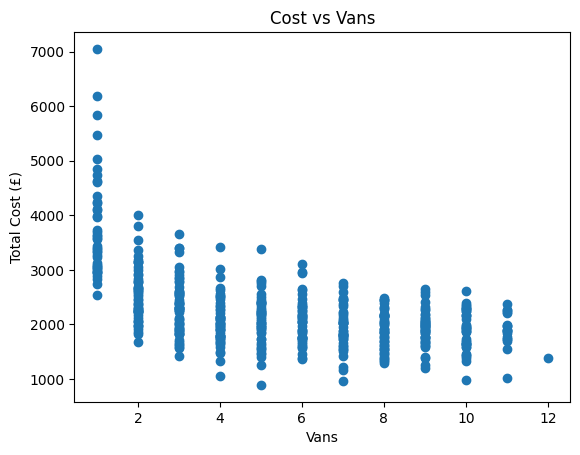

In [14]:
plt.figure()
plt.scatter(df['vans'], df['total_cost'])
plt.xlabel("Vans")
plt.ylabel("Total Cost (£)")
plt.title("Cost vs Vans")
plt.show()


Task 2 – Build & Select Cost Models

2.1 Create Utilisation Term

In [15]:
df['utilisation'] = df['demand'] / (df['vans'] * df['employees'])
df['util_sq'] = df['utilisation'] ** 2


2.2 Candidate Models

In [16]:
X1 = np.column_stack([
    np.ones(len(df)),
    df['demand'],
    df['vans'],
    df['employees']
])
y = df['total_cost'].values


Model 2 – With Utilisation

In [17]:
X2 = np.column_stack([
    np.ones(len(df)),
    df['demand'],
    df['vans'],
    df['employees'],
    df['utilisation']
])

Model 3 – Non-linear (chosen model)

In [18]:
X3 = np.column_stack([
    np.ones(len(df)),
    df['demand'],
    df['vans'],
    df['employees'],
    df['utilisation'],
    df['util_sq']
])


2.3 Fit Models (OLS – Manual)

In [19]:
def fit_ols(X, y):
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    y_hat = X @ beta
    sse = np.sum((y - y_hat) ** 2)
    return beta, sse

In [20]:
b1, sse1 = fit_ols(X1, y)
b2, sse2 = fit_ols(X2, y)
b3, sse3 = fit_ols(X3, y)

print("Model 1 SSE:", sse1)
print("Model 2 SSE:", sse2)
print("Model 3 SSE:", sse3)

Model 1 SSE: 158538917.67269918
Model 2 SSE: 57405776.475568876
Model 3 SSE: 54538811.465945296


Task 3 – Optimisation Using Gradient Descent

3.1 Fix Demand at Average

In [21]:
D_bar = df['demand'].mean()
print("Average demand:", D_bar)

Average demand: 96.222


3.2 Cost Function (from Model 3)

In [22]:
beta = b3

def cost(v, e):
    u = D_bar / (v * e)
    return (
        beta[0]
        + beta[1] * D_bar
        + beta[2] * v
        + beta[3] * e
        + beta[4] * u
        + beta[5] * u**2
    )

3.3 Gradient Descent Implementation

In [23]:
def gradient(v, e):
    u = D_bar / (v * e)
    
    dC_dv = (
        beta[2]
        - beta[4] * D_bar / (v**2 * e)
        - 2 * beta[5] * (D_bar**2) / (v**3 * e**2)
    )
    
    dC_de = (
        beta[3]
        - beta[4] * D_bar / (v * e**2)
        - 2 * beta[5] * (D_bar**2) / (v**2 * e**3)
    )
    
    return dC_dv, dC_de


In [24]:
# Gradient Descent
v, e = 5.0, 8.0
lr = 0.01

for i in range(5000):
    gv, ge = gradient(v, e)
    v -= lr * gv
    e -= lr * ge
    
    v = max(v, 0.1)
    e = max(e, 0.1)

print("Optimal vans (continuous):", v)
print("Optimal employees (continuous):", e)
print("Predicted cost:", cost(v, e))

Optimal vans (continuous): 9.328359450934412
Optimal employees (continuous): 8.50287708820758
Predicted cost: 1836.423484349106


3.4 Rounding Discussion

In [25]:
v_int = round(v)
e_int = round(e)

print("Rounded vans:", v_int)
print("Rounded employees:", e_int)
print("Rounded cost:", cost(v_int, e_int))


Rounded vans: 9
Rounded employees: 9
Rounded cost: 1837.0248844960972


Task 4 – Bootstrap Uncertainty Analysis

In [26]:
B = 500
boot_costs = []

for _ in range(B):
    sample = df.sample(len(df), replace=True)
    
    sample['utilisation'] = sample['demand'] / (sample['vans'] * sample['employees'])
    sample['util_sq'] = sample['utilisation'] ** 2
    
    Xb = np.column_stack([
        np.ones(len(sample)),
        sample['demand'],
        sample['vans'],
        sample['employees'],
        sample['utilisation'],
        sample['util_sq']
    ])
    
    yb = sample['total_cost'].values
    beta_b, _ = fit_ols(Xb, yb)
    
    u = D_bar / (v * e)
    c_pred = (
        beta_b[0]
        + beta_b[1] * D_bar
        + beta_b[2] * v
        + beta_b[3] * e
        + beta_b[4] * u
        + beta_b[5] * u**2
    )
    
    boot_costs.append(c_pred)


4.1 Confidence Interval

In [27]:
lower = np.percentile(boot_costs, 2.5)
upper = np.percentile(boot_costs, 97.5)
mean_cost = np.mean(boot_costs)

print("Mean predicted cost:", mean_cost)
print("95% CI:", (lower, upper))


Mean predicted cost: 1837.0607863025893
95% CI: (1791.2416911411044, 1887.2203983232357)


4.2 Bootstrap Plot

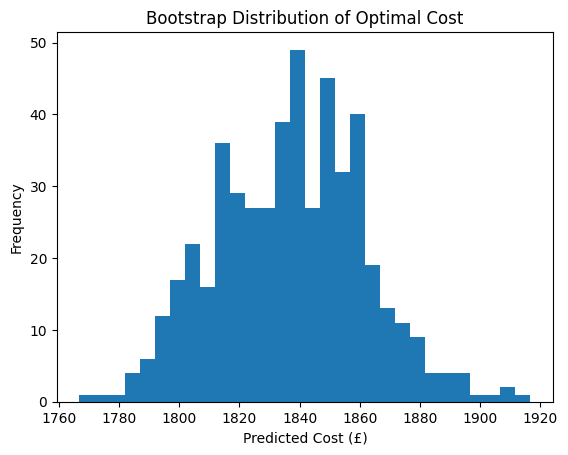

In [29]:
plt.figure()
plt.hist(boot_costs, bins=30)
plt.xlabel("Predicted Cost (£)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Optimal Cost")
plt.show()
